# 认识

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from astroquery.nist import Nist
import astropy.units as u
from astropy.table import Table
from astropy.io import fits
from astroquery.mast import Observations
from cos_functions import estimate_snr

fonts = ['Microsoft YaHei', 'SimHei', 'SimSun', 'sans-serif']
plt.rcParams['font.sans-serif'] = fonts
sns.set_theme(style="whitegrid", font=fonts)
# 设置全局高清显示（放在代码最前面）
plt.rcParams['figure.dpi'] = 150  # 屏幕显示清晰度
plt.rcParams['savefig.dpi'] = 300 # 保存图片的清晰度


## 物质波长

以氢原子为例， 我们可以看看在300到700nm波段中，他的一些波长

In [ ]:
table = Nist.query(300 * u.nm, 1500 * u.nm, linename="H I")

- `observed` 实验室实际测得波长
- `Ritz` 理论波长
- `Rel.` 相对光强。波长概率

In [10]:
print(table.colnames)

['Observed', 'Ritz', 'Transition', 'Rel.', 'Aki', 'fik', 'Acc.', 'Ei           Ek', 'Lower level', 'Upper level', 'gi   gk', 'Type', 'TP', 'Line']


In [32]:
def get_element_data(element_name="H I"):
    """ 获取物质的波长和光强. 300-700nm """
    table = Nist.query(300 * u.nm, 700 * u.nm, linename=element_name)
    df = table.to_pandas()
    
    result_df = pd.DataFrame()
    
    result_df['Wavelength'] = df['Observed'].fillna(df['Ritz'])

    def clean_rel(val):
        s = str(val).strip()
        nums = "".join([c for c in s if c.isdigit() or c == '.'])
        try:
            return float(nums) if nums else 0.0
        except:
            return 0.0
            
    result_df['Intensity'] = df['Rel.'].apply(clean_rel)
    
    result_df['Element'] = element_name
    return result_df


In [51]:
elements = ['O III', 'H I', 'CA II', 'He I', 'Na I', 'Mg I']
dfs = [get_element_data(ele)  for ele in elements]
df = pd.concat(dfs)

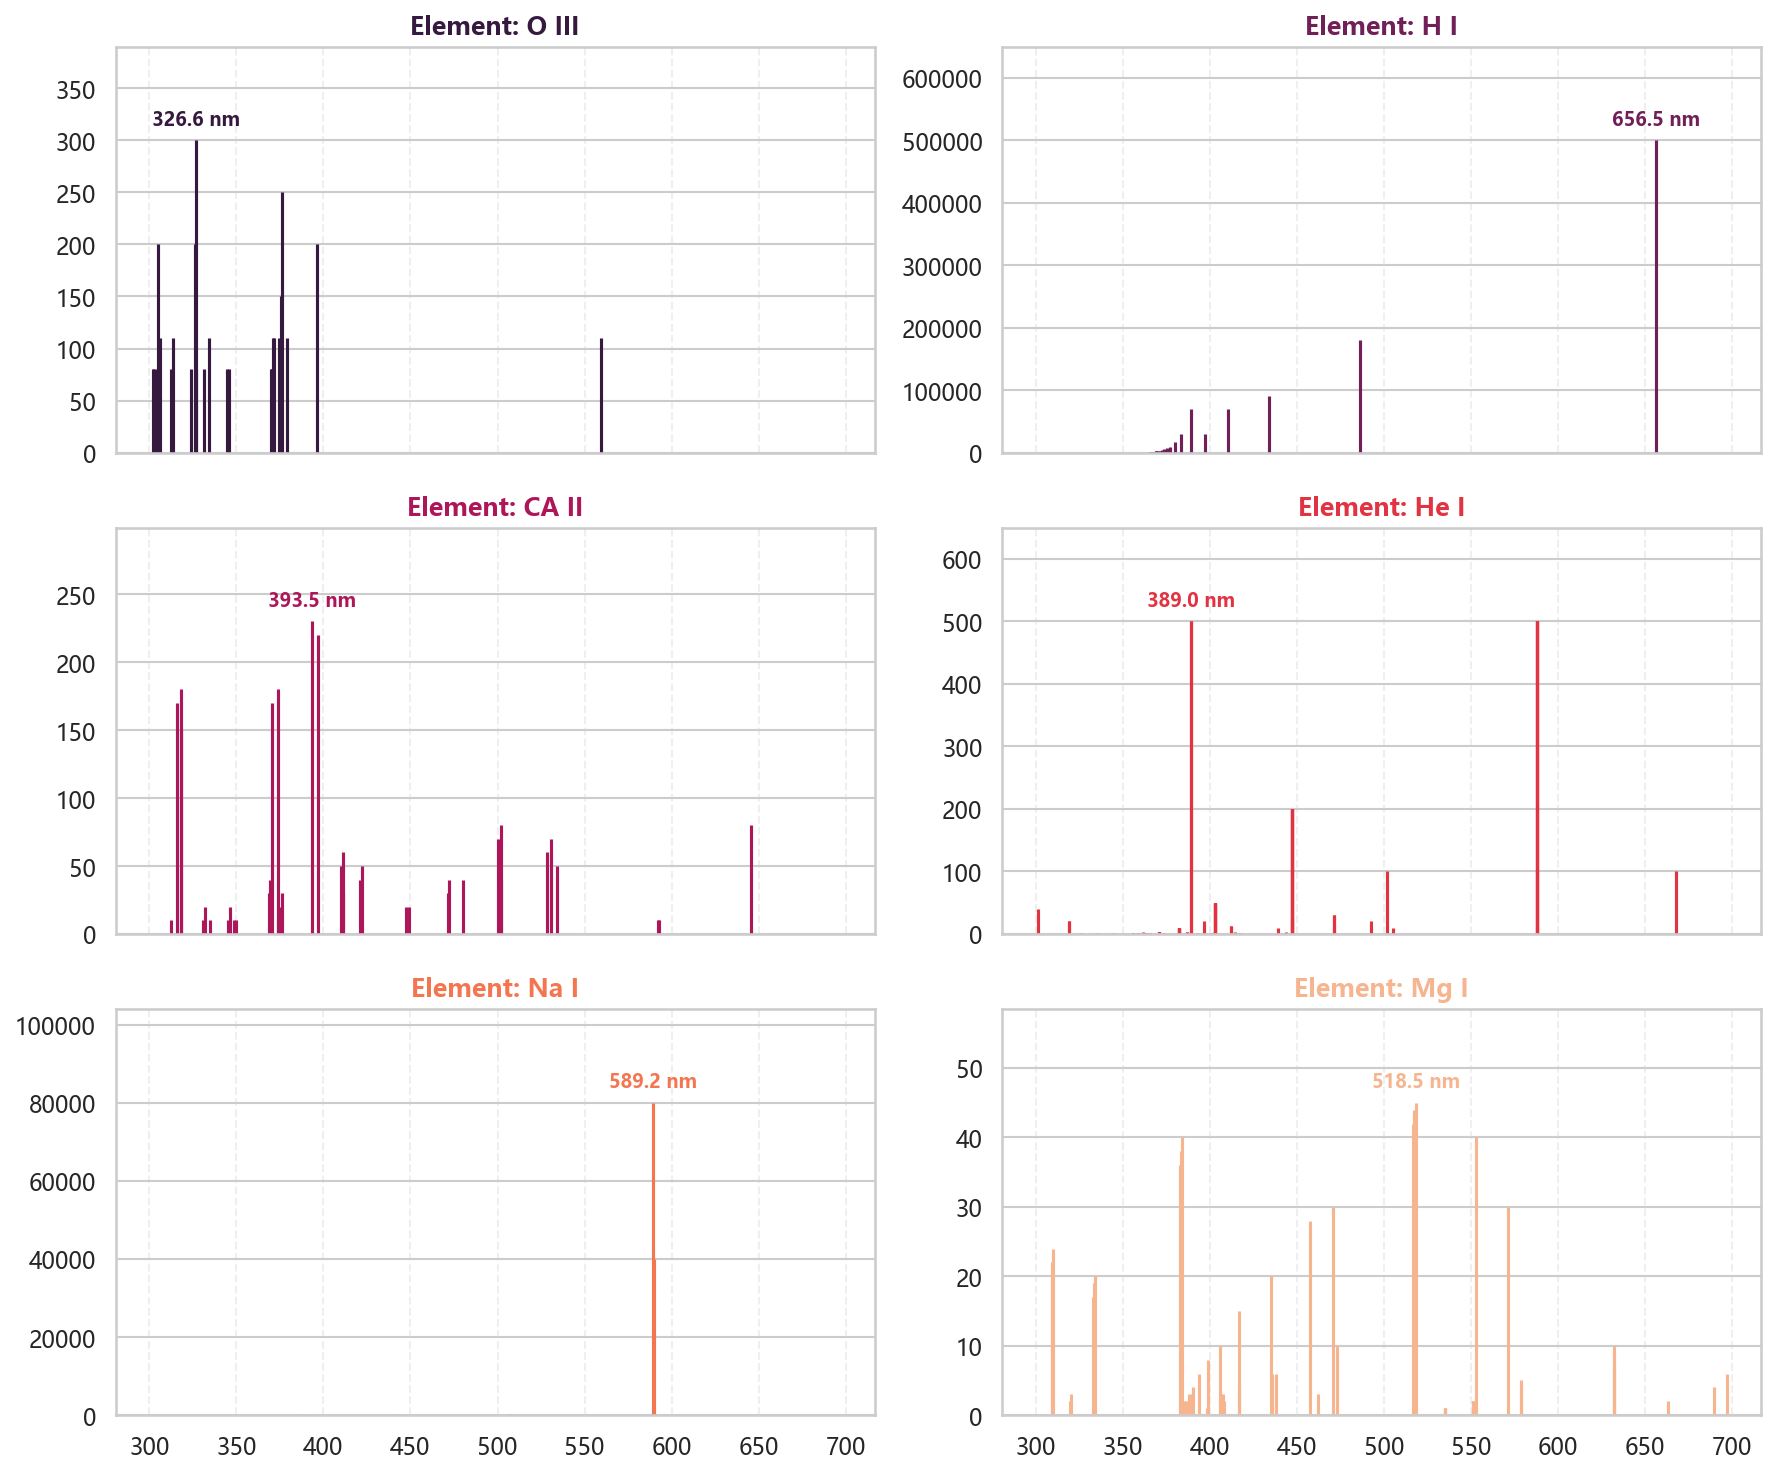

In [54]:
colors = sns.color_palette("rocket", len(elements))
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True) 
axes_flat = axes.flatten()

for i, name in enumerate(elements):
    ax = axes_flat[i]
    subset = df[df['Element'] == name]
    
    # 1. 绘制谱线
    ax.vlines(subset['Wavelength'], 0, subset['Intensity'], 
              colors=colors[i], linewidth=1.5)
    
    # 2. 找到最强峰值并标注 (Peak Picking)
    if not subset.empty:
        # 获取最强线的数据点
        peak = subset.loc[subset['Intensity'].idxmax()]
        peak_w = peak['Wavelength']
        peak_i = peak['Intensity']
        
        # 在峰值上方添加文字标注
        ax.annotate(f'{peak_w:.1f} nm', 
                    xy=(peak_w, peak_i), 
                    xytext=(0, 5),          # 向上偏移 5 个点
                    textcoords='offset points',
                    ha='center',            # 水平居中
                    va='bottom',            # 垂直底部对齐
                    fontsize=9,
                    fontweight='bold',
                    color=colors[i])

    # 3. 样式设置
    ax.set_title(f"Element: {name}", fontsize=12, color=colors[i], fontweight='bold')
    ax.set_ylim(0, subset['Intensity'].max() * 1.3) # 增加高度比例(1.3)给文字留空间
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


## astroquery 库
https://astroquery.readthedocs.io/en/latest/
- 从各种望远镜获取数据

获取一次任务，表示某个望远镜的一次曝光。

In [ ]:
Observations.query_criteria(obs_id="LDM701020")

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str3,str6,str7,str3,str5,str2,str4,str11,str9,float64,float64,str8,str14,int64,float64,float64,float64,float64,float64,str34,float64,str5,str7,int64,str417,str37,str38,str6,bool,float64,str8,str10
science,HST,CALCOS,COS/FUV,HST,G160M,UV,AV75,EXT-STAR;OF,ldm701020,12.63495833333,-72.8768,spectrum,"Fox, Andrew J.",3,57975.28908387732,57975.353713310185,2070.048,140.5,177.5,COS FUV Spectral Resolution at LP4,57975.6088657,15366,CAL/COS,--,POLYGON 12.63613764 -72.8768 12.63603567 -72.87665877 12.63574743 -72.87654196 12.63532275 -72.87646977 12.63483506 -72.87645468 12.63436869 -72.8764993 12.63400426 -72.87659591 12.6338048 -72.87672781 12.63380479 -72.87687219 12.63400424 -72.87700409 12.63436867 -72.8771007 12.63483506 -72.87714532 12.63532276 -72.87713023 12.63574745 -72.87705803 12.63603569 -72.87694122 12.63613764 -72.8768 12.63613764 -72.8768,mast:HST/product/ldm701020_x1dsum.png,mast:HST/product/ldm701020_x1dsum.fits,PUBLIC,False,nan,25868963,1007521450
